In [21]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
import seaborn as sns
from scipy.stats import pearsonr, spearmanr, mannwhitneyu, ttest_ind, ks_2samp
from sklearn.metrics import average_precision_score, roc_auc_score
from sklearn.utils import resample

from matplotlib.colors import LinearSegmentedColormap
import mpl_scatter_density # needed for density scatter plots
from astropy.visualization import LogStretch
from astropy.visualization.mpl_normalize import ImageNormalize

# COLORS:
# "Viridis-like" colormap with white background
white_viridis = LinearSegmentedColormap.from_list("white_viridis", [
    (0, "#ffffff"),
    (1e-20, "#440053"),
    (0.2, "#404388"),
    (0.4, "#2a788e"),
    (0.6, "#21a784"),
    (0.8, "#78d151"),
    (1, "#fde624"),
], N=256)
# "Viridis-like" colormap with white background
white_viridis_r = LinearSegmentedColormap.from_list("white_viridis", [
    (0, "#ffffff"),
    (1e-20, "#fde624"),
    (0.4, "#78d151"),
    (0.6, "#21a784"),
    (0.7, "#2a788e"),
    (0.8, "#404388"),
    (1, "#440053"),
], N=256)
prop_cycle = plt.rcParams["axes.prop_cycle"]
colors = prop_cycle.by_key()["color"]

In [3]:
print(
    "scp cbsu:/home2/ayh8/clipnet_k562/data/mpra/k562_allelic_mpra_snps.csv.gz ~/github/clipnet_k562/siraj_mpra"
)

scp cbsu:/home2/ayh8/clipnet_k562/data/mpra/k562_allelic_mpra_snps.csv.gz ~/github/clipnet_k562/siraj_mpra


In [4]:
data = pd.read_csv("~/github/clipnet_k562/siraj_mpra/k562_allelic_mpra_snps.csv.gz")

In [5]:
data["pred"] = np.log2(data["ref"] / data["alt"])
data["pred_procapnet"] = np.log2(data["ref_procapnet_ensemble"] / data["alt_procapnet_ensemble"])
for i in range(7):
    data[f"procapnet_fold_{i}"] = np.log2(data[f"ref_procapnet_fold_{i}"] / data[f"alt_procapnet_fold_{i}"])
data = data[np.isfinite(data["pred"])]
data.dropna(inplace=True)
#null_data = data[data.emVar_K562 == 0]
#data = data[data.emVar_K562 == 1]

/Users/adamhe/miniforge3/envs/plt/lib/python3.12/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: divide by zero encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [6]:
data[data.fold==0]

,fold,ref,alt,ref_procapnet_ensemble,alt_procapnet_ensemble,variant,ref_procapnet_fold_0,alt_procapnet_fold_0,ref_procapnet_fold_1,alt_procapnet_fold_1,...,expt,pred,pred_procapnet,procapnet_fold_0,procapnet_fold_1,procapnet_fold_2,procapnet_fold_3,procapnet_fold_4,procapnet_fold_5,procapnet_fold_6
46864,0,11.767554,11.933134,5.799024,5.812474,chr9:40997:A:T,5.515966,5.524892,6.268514,6.294829,...,0.296676,-0.020159,-0.003342,-0.002333,-0.006044,-0.000942,-0.001186,-0.004274,-0.006148,-0.002443
46865,0,10.378619,10.327922,5.788856,5.775773,chr9:43862:A:T,5.475117,5.473865,6.238721,6.224415,...,-0.237110,0.007064,0.003264,0.000330,0.003312,0.000540,-0.001664,0.001027,0.002426,0.017170
46866,0,11.583302,11.391767,5.769773,5.743348,chr9:46587:C:T,5.449307,5.429379,6.284638,6.275517,...,0.160731,0.024055,0.006623,0.005286,0.002095,0.013077,0.005914,0.006762,0.004734,0.008661
46867,0,12.315641,12.009182,5.786134,5.762557,chr9:47242:C:T,5.494717,5.486424,6.223524,6.223015,...,0.528568,0.036354,0.005891,0.002179,0.000118,0.007410,0.004335,0.007301,0.008200,0.012138
46868,0,12.176400,12.492646,5.683757,5.678206,chr9:47303:A:G,5.442106,5.430796,6.182661,6.171495,...,-0.439738,-0.036991,0.001410,0.003001,0.002608,0.004228,0.003456,0.000851,-0.005250,0.000291
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
281286,0,11.262746,11.213558,5.972973,5.978326,chr13:76792248:G:A,5.688604,5.683801,6.479054,6.500929,...,0.530846,0.006315,-0.001292,0.001219,-0.004863,-0.000599,-0.001566,-0.001919,-0.001663,0.000789
281290,0,11.223577,10.990559,5.798469,5.802187,chr20:19501393:G:A,5.506838,5.520019,6.325845,6.336660,...,-0.160334,0.030268,-0.000925,-0.003449,-0.002464,0.000927,-0.000424,-0.002477,-0.001934,0.003345
281310,0,11.683129,11.745498,5.714543,5.728315,chr20:60911958:G:A,5.436740,5.437465,6.171861,6.170341,...,0.316090,-0.007681,-0.003473,-0.000192,0.000355,-0.004300,-0.004951,-0.006120,-0.006498,-0.002839
281314,0,10.567259,10.654262,5.917876,5.940185,chr13:57606694:G:A,5.647520,5.663898,6.396679,6.412116,...,-0.172244,-0.011829,-0.005428,-0.004178,-0.003478,-0.002298,-0.005114,-0.005905,-0.005861,-0.011480


In [7]:
average_precision_score(data[data.fold==0].emVar_K562, data[data.fold==0].pred ** 2)

0.20298982594790085

In [8]:
average_precision_score(data[data.fold==0].emVar_K562, data[data.fold==0].pred_procapnet ** 2)

0.180821950078469

In [28]:
procapnet_map_bootstrap = []
clipnet_map_bootstrap = []

for i in range(1000):
    emvar, clipnet, procapnet = resample(
        data[data.fold==0].emVar_K562,
        data[data.fold==0].pred ** 2,
        data[data.fold==0].pred_procapnet ** 2
    )
    clipnet_map_bootstrap.append(average_precision_score(emvar, clipnet))
    procapnet_map_bootstrap.append(average_precision_score(emvar, procapnet))

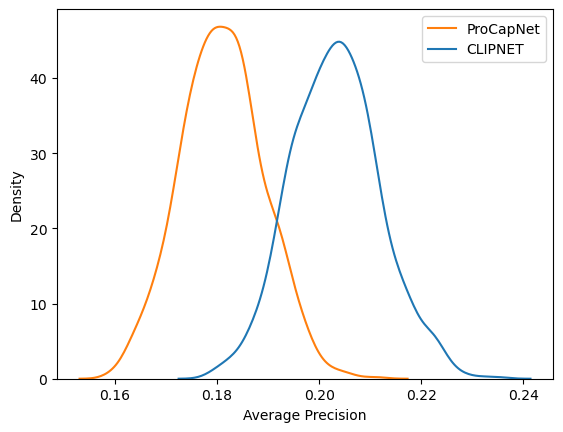

In [29]:
sns.kdeplot(procapnet_map_bootstrap, label="ProCapNet", color=colors[1])
sns.kdeplot(clipnet_map_bootstrap, label="CLIPNET", color=colors[0])
plt.xlabel("Average Precision")
plt.ylabel("Density")
plt.legend()

In [30]:
mannwhitneyu(procapnet_map_bootstrap, clipnet_map_bootstrap)

MannwhitneyuResult(statistic=30285.0, pvalue=1.0642992330920473e-289)

In [31]:
ttest_ind(procapnet_map_bootstrap, clipnet_map_bootstrap)

TtestResult(statistic=-59.06012445261967, pvalue=0.0, df=1998.0)

Text(0.5, 0, 'CLIPNET - ProCapNet Average Precision')

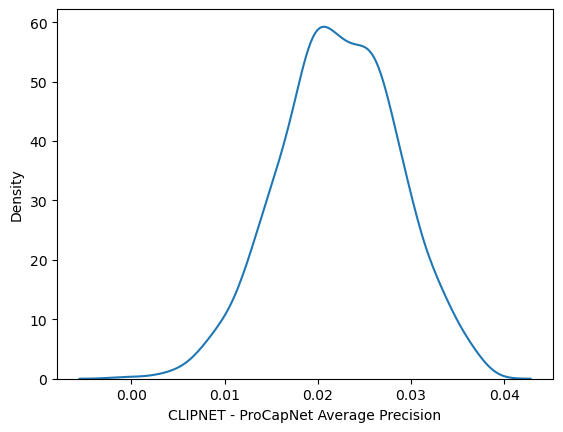

In [36]:
sns.kdeplot(np.array(clipnet_map_bootstrap) - np.array(procapnet_map_bootstrap))
plt.xlabel("CLIPNET - ProCapNet Average Precision")

In [40]:
((np.array(clipnet_map_bootstrap) - np.array(procapnet_map_bootstrap)) <= 0).mean()

0.001